Question 3

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import KFold, train_test_split


In [7]:
# Function to load dataset
directions = ["down","up","rightturn","leftturn","forward","backward","left","right","none"]
def load_data():

    features = []
    labels = []

    for k, direction in enumerate(directions):
        for i in range(1,81):
            try:
                df = pd.read_csv(f"../{direction}/{direction}_{i:02}.csv", usecols=['accl_x', 'accl_y', 'accl_z', 'gyro_x', 'gyro_y', 'gyro_z'])

                # Keep only accelerometer and gyroscope signals
                data = df[['accl_x', 'accl_y', 'accl_z', 'gyro_x', 'gyro_y', 'gyro_z']].values[:250].astype(np.float32)
                
                # Normalize data
                data = (data - data.min(axis=0)) / (data.max(axis=0) - data.min(axis=0))
                
                # Populate lists with normalized data and labels
                features.append(data.flatten())

                # print(data.shape)
                labels.append(direction)
            except:
                print((data.max(axis=0) - data.min(axis=0)))

    return np.array(features), np.array(labels)

In [8]:
X, Y = load_data()
# Combine data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [9]:
def classification_error(y_pred, y_test):
    res = []
    for i in range(len(y_test)):
        res.append(y_pred[i] != y_test[i])
    return np.mean(res)

### SVM


['backward' 'down' 'forward' 'left' 'leftturn' 'none' 'right' 'rightturn'
 'up']
pred, actual, confidence score
none forward 0.4309437541522112
backward none 0.409426076406591
down forward 0.2992247515756455
none up 0.3009531646727829
up rightturn 0.44128351558116224
down forward 0.628163714328452
backward none 0.25994510928100956
forward none 0.6572302833770807
none up 0.579015559718161
leftturn forward 0.7157174067740335
backward none 0.344209252808911
down none 0.36248351271633306
backward leftturn 0.2867518253426657
none down 0.9177106246892411
up rightturn 0.47368033224882095
up none 0.3275653314276285
backward forward 0.600731653842758
none down 0.482269822452569
leftturn forward 0.5300650175447974
none forward 0.5645059710374911
down none 0.4049486921989607
none rightturn 0.7280994468415215
SVM accuracy: 84.72222222222221


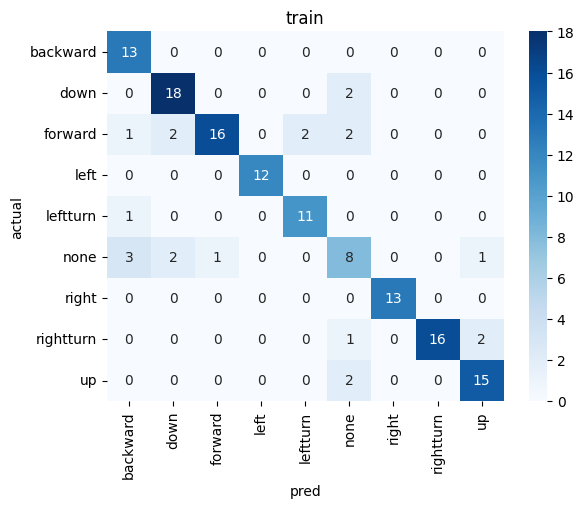

In [10]:
# def train_and_evaluate_svm(X_train, y_train, X_test, y_test):
    # Create the SVM classifier
svm_classifier = SVC(kernel='poly',C = 1, gamma=0.01, probability=True)
# Train the classifier
svm_classifier.fit(X_train, y_train)
# Perform prediction on the test set
y_pred = svm_classifier.predict(X_test)
# conf_score = svm_classifier.decision_function(X_test).argmax(axis=1)
cs = svm_classifier.predict_proba(X_test)
# y_pred = list(map(lambda x: svm_classifier.classes_[x], conf_score.tolist()))

print(svm_classifier.classes_)
print("pred, actual, confidence score")
for i in range(len(y_pred)):
    if y_pred[i] != y_test[i]:
        print(y_pred[i], y_test[i], cs[i].max())
# Evaluate the model
print(f'SVM accuracy: {accuracy_score(y_pred, y_test)*100}')

# Plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, cmap="Blues", xticklabels=svm_classifier.classes_, yticklabels=svm_classifier.classes_)
plt.title('train')
plt.xlabel('pred')
plt.ylabel('actual')
plt.show()